# Chapter 5. Decision Trees

Decision trees are versatile machine learning algorithms capable of performing classification and regression tasks. They are intuitive white box models meaning their decision making processes are easy to interpret and explain.

One of the greatest engineering advantages of decision trees is that they require very little data preparation. They do not require any feature scaling or centering.

### Training and Visualizing

Let's build a basic decision tree to classify the Iris dataset based on petal dimensions.

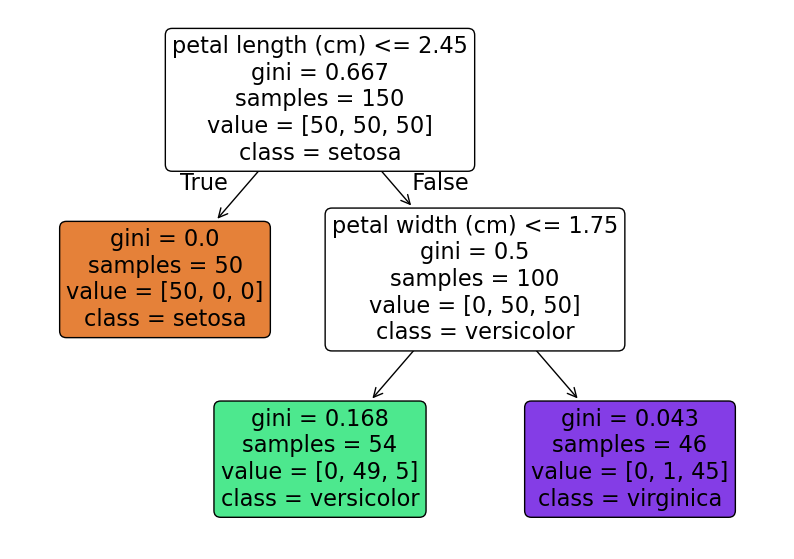

In [3]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree


# Load dataset as a pandas DataFrame
iris = load_iris(as_frame=True)
X_iris = iris.data[['petal length (cm)', 'petal width (cm)']].values
y_iris = iris.target

# Train a Decision Tree constrained to a maximum depth of 2
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

# Visualize the trained decision tree
plt.figure(figsize=(10, 7))
plot_tree(tree_clf, 
          feature_names=['petal length (cm)', 'petal width (cm)'],  
          class_names=iris.target_names, 
          filled=True, 
          rounded=True)
plt.show()

## Making Predictions and Gini Impurity

A decision tree predicts a class by starting at the root node and traversing down to a leaf node by answering yes or no questions about the features.

The algorithm decides how to split the data by evaluating the impurity of the resulting nodes. Scikit-Learn uses the Gini impurity metric by default. A node is perfectly pure ($G=0$) if all its training instances belong to a single class.

$$G_i = 1 - \sum_{k=1}^{n} p_{i,k}^2$$

Where $p_{i,k}$ is the ratio of class $k$ instances among the training instances in the $i$th node.

## Estimating Class Probabilities

A decision tree can estimate the probability that an instance belongs to a particular class. It traverses the tree to find the appropriate leaf node and returns the ratio of training instances for each class that fall into that exact node. The model then simply predicts the class with the highest probability.

**Note:**
The estimated probabilities remain exactly identical anywhere within the same decision boundary rectangle. Even if a new data point is visually far away from the training cluster as long as it falls into the same leaf node region the decision tree will confidently output the exact same probability.

In [6]:
flower_example = [[5, 1.5]]

print('Class Probabilities \n', tree_clf.predict_proba(flower_example).round(3))
print('Predicted Class \n', tree_clf.predict(flower_example))

Class Probabilities 
 [[0.    0.907 0.093]]
Predicted Class 
 [1]


## The CART Training Algorithm

Scikit Learn uses the Classification and Regression Tree (CART) algorithm to train decision trees. It is a greedy algorithm that searches for the single feature $k$ and threshold $t_k$ that produces the purest subsets weighted by their size.

$$J(k, t_k) = \frac{m_{\text{left}}}{m} G_{\text{left}} + \frac{m_{\text{right}}}{m} G_{\text{right}}$$

Finding the absolutely optimal tree is an NP complete problem requiring $O(\exp(m))$ time. Therefore the CART algorithm settles for a reasonably good solution rather than the guaranteed optimal one.

## Computational Complexity

Making predictions requires traversing roughly $O(\log_2(m))$ nodes. Because each node only evaluates one feature, predictions are extremely fast regardless of the total number of features. Training complexity is $O(n \times m \log_2(m))$ because the training algorithm compares all features on all samples at each node.

## Gini Impurity or Entropy

By default the `DecisionTreeClassifier` class uses the Gini impurity measure. You can select the entropy impurity measure instead by setting the `criterion` hyperparameter to entropy.

The concept of entropy originated in thermodynamics and information theory. In machine learning, a set's entropy is exactly zero when it contains instances of only one class.

$$H_i = -\sum_{k=1}^{n} p_{i,k} \log_2(p_{i,k}), \quad p_{i,k} \neq 0$$

**Choosing the Right Metric:**
Most of the time it does not make a significant difference as they mathematically lead to very similar trees. 

* Gini impurity is slightly faster to compute making it an excellent default choice for production environments.
* When they do differ Gini impurity tends to isolate the most frequent class in its own branch.
* Entropy tends to produce slightly more balanced trees due to its logarithmic penalty.

### Regularization Hyperparameters

Decision trees are nonparametric models. If left unconstrained the tree structure will freely adapt to perfectly fit the training data leading to severe overfitting. To prevent this we must regularize the model by restricting its freedom during training.

* `max_depth` Restricts the maximum depth of the decision tree
* `max_features` Maximum number of features evaluated for splitting at each node
* `max_leaf_nodes` Maximum number of leaf nodes allowed
* `min_samples_split` Minimum number of samples a node must have before it can be split
* `min_samples_leaf` Minimum number of samples a leaf node must have to be created
* `min_weight_fraction_leaf` Same as min_samples_leaf but expressed as a fraction of the total weighted instances
* `min_impurity_decrease` Only split a node if the split results in at least this much reduction in impurity
* `ccp_alpha` Controls minimal cost complexity pruning allowing you to prune subtrees that do not reduce impurity enough

To limit the model’s complexity, you can increase `min_*` hyperparameters or `ccp_alpha`, or decrease `max_*` hyperparameters. Tuning `max_depth` is usually a good default.

Let's prove this by training two trees on a complex dataset one unregularized and one regularized.

In [20]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=150, noise=0.2, random_state=42)

tree_clf1 = DecisionTreeClassifier(random_state=42)
tree_clf2 = DecisionTreeClassifier(min_samples_leaf=5, random_state=42)
tree_clf1.fit(X_moons, y_moons)
tree_clf2.fit(X_moons, y_moons)

X_moons_test, y_moons_test = make_moons(n_samples=1000, noise=0.2,
                                        random_state=43)
print('Unregularized Model Accuracy \n', tree_clf1.score(X_moons_test, y_moons_test))
print('Regularized Model Accuracy \n', tree_clf2.score(X_moons_test, y_moons_test))

Unregularized Model Accuracy 
 0.898
Regularized Model Accuracy 
 0.92


## Regression

Decision trees can perform regression tasks with high flexibility. Instead of predicting a categorical class a regression tree predicts a continuous numerical value. The predicted value is mathematically the average target value of all training instances associated with that specific leaf node.

### The CART Training Algorithm for Regression

The CART algorithm works similarly to classification. However instead of splitting the training set to minimize impurity it splits the data to minimize the Mean Squared Error.

$$J(k, t_k) = \frac{m_{\text{left}}}{m} \text{MSE}_{\text{left}} + \frac{m_{\text{right}}}{m} \text{MSE}_{\text{right}}$$

Just like classification tasks regression trees are highly prone to overfitting. Without regularization the model will create excessively fine splits to hit every single training instance. Applying hyperparameters like `min_samples_leaf` is essential to achieve a reasonable and generalized model.

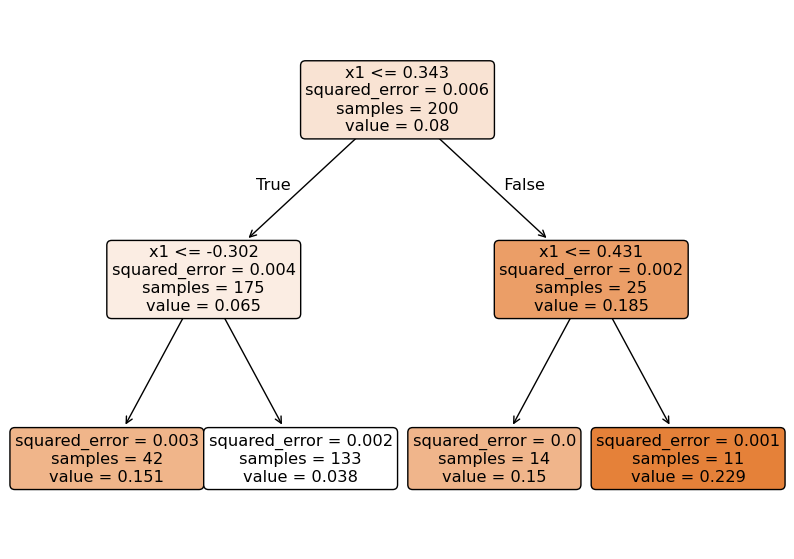

In [26]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

# Generate a noisy quadratic dataset
rng = np.random.default_rng(seed=42)
X_quad = rng.random((200, 1)) - 0.5 # a single random input feature
y_quad = X_quad ** 2 + 0.025 * rng.standard_normal((200, 1))

# Train a Regression Tree with restricted depth to prevent overfitting
tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_quad, y_quad)

# Visualize the trained decision tree
plt.figure(figsize=(10, 7))
plot_tree(tree_reg, 
          feature_names=['x1'],   
          filled=True, 
          rounded=True)
plt.show()